In [1]:
%cd /home/smalani/PartialObservations/

from BandFModel import plot_and_metric_BandF

addon = "greybox_trainable/"
master_filename = "/home/smalani/PartialObservations/data/" + addon
save_filename = "/home/smalani/PartialObservations/Figures/" + addon

/home/smalani/PartialObservations


In [2]:
## Black Box Resonance Trainable Metrics

%cd /home/smalani/PartialObservations
from BandFModel import plot_and_metric_BandF
import numpy as np

# RHS Hairs
L1_error_arr = []
L2_error_arr = []
Linf_error_arr = []


from config import config
config["MODEL"]["BOX"] = 'Grey'
config["MODEL"]["Parameters"] = 'Trainable'

for i in range(10):
    # if i == 2 or i == 4:
    #     continue
    filename = master_filename + "model_run_" + str(i) + ".net"

    RHS_hair_error_trueLC_True, RHS_hair_error_trueLC_Pred, L1_error, L2_error, Linf_error = \
        plot_and_metric_BandF.metric_hair_fromTrue(filename=filename, make_plots=False)
    # print('===============================')
    # print(root_pred)
    # print('===============================')

    L1_error_arr.append(L1_error)
    L2_error_arr.append(L2_error)
    Linf_error_arr.append(Linf_error)

BB_bestcase = np.argmin(L2_error_arr)
print("BEST BLACK BOX RUN")
print(BB_bestcase)
print(L2_error_arr)


print("Black Box Solution Errors")
print(np.average(L1_error_arr))
print(np.std(L1_error_arr))
print('===============')
print(np.average(L2_error_arr))
print(np.std(L2_error_arr))
print('===============')
print(np.average(Linf_error_arr))
print(np.std(Linf_error_arr))

L1_error_arr = []
L2_error_arr = []
Linf_error_arr = []

for i in range(10):
    # if i == 2 or i == 4:
    #     continue
    filename = master_filename + "model_run_" + str(i) + ".net"

    root_pred = None
    output, ANN_output, output_LC, ANN_output_LC, L1_error, L2_error, Linf_error = \
        plot_and_metric_BandF.metric_RHS(filename=filename, make_plots=False)
    # print('===============================')
    # print(root_pred)
    # print('===============================')

    L1_error_arr.append(L1_error)
    L2_error_arr.append(L2_error)
    Linf_error_arr.append(Linf_error)

print("Black Box RHS Errors")
print(np.average(L1_error_arr))
print(np.std(L1_error_arr))
print('===============')
print(np.average(L2_error_arr))
print(np.std(L2_error_arr))
print('===============')
print(np.average(Linf_error_arr))
print(np.std(Linf_error_arr))

/home/smalani/PartialObservations
/home/smalani/PartialObservations/data/greybox_trainable/model_run_0.net
/home/smalani/PartialObservations/data/greybox_trainable/model_run_1.net
/home/smalani/PartialObservations/data/greybox_trainable/model_run_2.net
/home/smalani/PartialObservations/data/greybox_trainable/model_run_3.net
/home/smalani/PartialObservations/data/greybox_trainable/model_run_4.net
/home/smalani/PartialObservations/data/greybox_trainable/model_run_5.net
/home/smalani/PartialObservations/data/greybox_trainable/model_run_6.net
/home/smalani/PartialObservations/data/greybox_trainable/model_run_7.net
/home/smalani/PartialObservations/data/greybox_trainable/model_run_8.net
/home/smalani/PartialObservations/data/greybox_trainable/model_run_9.net
BEST BLACK BOX RUN
0
[0.00428197921618803, 0.004739830552428479, 0.005003262434844467, 0.014052830526239655, 0.0054447019253941464, 0.006317947095650095, 0.004463248276716321, 0.00569622547726588, 0.0060080760744891755, 0.00503817912476

/home/smalani/PartialObservations
/home/smalani/PartialObservations/data/greybox_trainable/model_run_0.net


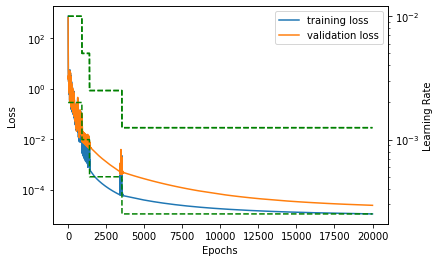

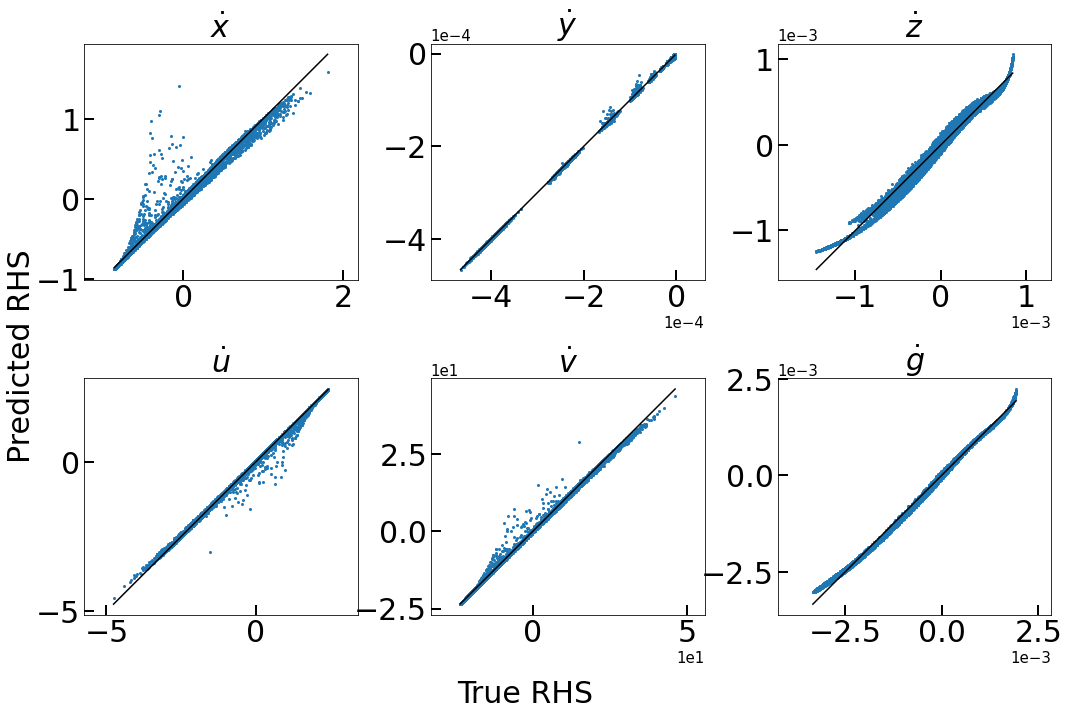

In [3]:
%cd /home/smalani/PartialObservations
# BB_bestcase = 9
from main import preprocess
from BandFModel import datagen, plot_and_metric_BandF
from config import config

import matplotlib.pyplot as plt 
import numpy as np

filename = filename = master_filename + "model_run_" + str(BB_bestcase)

train_loss = np.load(filename + '_training_loss.npy')
val_loss = np.load(filename + '_validation_loss.npy')
epoch_list = np.load(filename + '_lr_epoch.npy')
lr_list = np.load(filename + '_lr_track.npy', allow_pickle=True)

fig, ax2 = plt.subplots()
ax2.semilogy(range(train_loss.shape[0]),train_loss,label='training loss')
ax2.semilogy(range(train_loss.shape[0]),val_loss,label='validation loss')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
plt.legend()
ax = ax2.twinx()
ax.semilogy(epoch_list,lr_list,'g--')
ax.set_xlabel('Epochs')
ax.set_ylabel('Learning Rate')

plt.savefig(save_filename + 'TrainingCurve_' + str(BB_bestcase) + '.png')

filename = filename = master_filename + "model_run_" + str(BB_bestcase) + ".net"

output, ANN_output, output_LC, ANN_output_LC, L1_error, L2_error, Linf_error = \
        plot_and_metric_BandF.metric_RHS(filename=filename, make_plots=False)

fig = plt.figure(figsize=(15,10))

labels = ['$\dot{x}$', '$\dot{y}$', '$\dot{z}$', '$\dot{u}$', '$\dot{v}$', '$\dot{g}$']
for i in range(6):
    ax = plt.subplot(int(str(23) + str(i+1)))
    axplot = ax.scatter(output[:,i], ANN_output[:,i], s=4)
    # axplot = ax.scatter(output_LC[:,i], ANN_output_LC[:,i], s=4)
    ax.plot([np.min(output[:,i]), np.max(output[:,i])],[np.min(output[:,i]), np.max(output[:,i])], 'k-')
    # ax.tick_params(axis='y', labelsize=20)
    ax.ticklabel_format(axis="y", style="sci", scilimits=(0,0))
    ax.yaxis.offsetText.set_fontsize(15)
    ax.tick_params(axis='both', labelsize=30, direction='in', length=10, width=2)
    ax.ticklabel_format(axis="x", style="sci", scilimits=(0,0))
    ax.xaxis.offsetText.set_fontsize(15)
    ax.set_title(labels[i], fontsize=30)
    ax.set_aspect("equal", adjustable="datalim")

# plt.suptitle('Predicted RHS vs True RHS', fontsize=40)

fig.supylabel('Predicted RHS', fontsize=30)
fig.supxlabel('True RHS', fontsize=30)
plt.tight_layout()
plt.savefig(save_filename + 'RHSPred_Model_Run_' + str(BB_bestcase) + '.png')

# plot_and_metric_BandF.make_poincare_maps(filename, make_plots=True, savefilename = 'Figures/blackbox_resonance/BB_Resonance_badinit_poincaremap_Model_Run_' + str(BB_bestcase) + '.png')

/home/smalani/PartialObservations


  0%|          | 0/2 [00:00<?, ?it/s]

pakapaaakaaa detail
(2, 6)
/home/smalani/PartialObservations/data/greybox_trainable/model_run_0.net
49


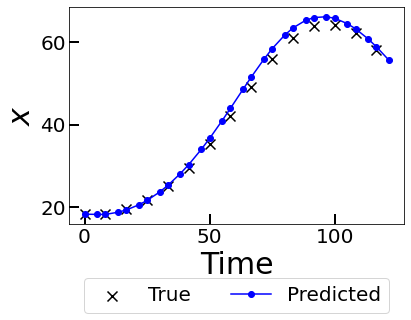

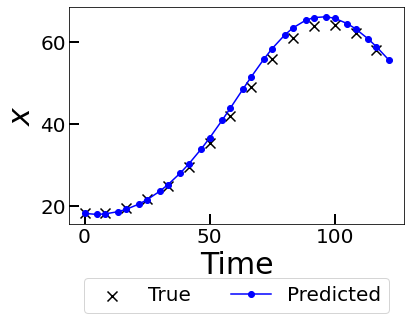

In [7]:
%cd /home/smalani/PartialObservations

from main import preprocess
from BandFModel import datagen, plot_and_metric_BandF
from config import config
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

np.random.seed(1234)



data_train = datagen.generate_data(n_train=2, duplicate_reverse=config["DATA"]["DUP_REVERSE"], detail=True)
dataset_train = preprocess.Dataset(*data_train[:2], duplicate_reverse=config["DATA"]["DUP_REVERSE"])

dataset_true = preprocess.Dataset(*data_train[:2])

# BB_bestcase = 0
filename = filename = master_filename + "model_run_" + str(BB_bestcase) + ".net"
network = plot_and_metric_BandF.load_model(filename=filename)

import torch

index = 0
print(len(dataset_true.full_times_arr[index]))

myrangefirst = 0
myrangesecond = myrangefirst + 30

x = torch.tensor(dataset_true.x[dataset_true.ids[index],myrangefirst:myrangesecond,:]).unsqueeze(0),
p = torch.tensor(dataset_true.p[dataset_true.ids[index],myrangefirst:myrangesecond,:]).unsqueeze(0),
t = torch.tensor(dataset_true.full_times_arr[dataset_true.ids[index]])[myrangefirst:myrangesecond].unsqueeze(-1).unsqueeze(0),

x_in = x[0][:,:-1,:]
t_in = t[0] - t[0][0,0,0]

network.tf_prop = 0
xout_hat = network(x_in.to(network.device), p[0].to(network.device), t_in.to(network.device), index)

plt.figure()
ax = plt.subplot(111)
ax.scatter(t_in[...,0].squeeze(),x[0][...,0].squeeze(),c='k',s=100,marker='x', label='True')
ax.plot(t_in[...,0].squeeze(),xout_hat[0][...,0].detach().cpu().numpy().squeeze(),'bo-', label='Predicted')
ax.tick_params(axis='both', labelsize=20, direction='in', length=10, width=2)
ax.set_xlabel('Time', fontsize=30)
ax.set_ylabel('$x$', fontsize=30)
lgd = ax.legend(loc='upper center', bbox_to_anchor=(0.5,-0.2), fontsize=20, ncol=2)
plt.savefig(save_filename + 'NNiter_Traj_Model_Run_' 
        + str(BB_bestcase) + '.png', bbox_extra_artists=(lgd,), bbox_inches='tight')

def ode_NN_func(t,x,p):
    x_in = torch.tensor(x).reshape((-1,6)).to(network.device)
    p_in = torch.tensor(p).reshape((-1,1)).to(network.device)
    return network.output(x_in, p_in).cpu().detach().numpy()

T = t_in[0,-1,0]
teval = t_in[0,:,0]
init = x[0][:,0,:].squeeze().numpy()
sol_pred = solve_ivp(ode_NN_func, y0=init, t_span=[0, T],
                                t_eval=teval, args=([6]),
                                rtol=1e-5, atol=1e-8)
plt.figure()
ax = plt.subplot(111)
ax.scatter(t_in[...,0].squeeze(),x[0][...,0].squeeze(),c='k',s=100,marker='x', label='True')
ax.plot(sol_pred.t,sol_pred.y[0,:],'bo-', label='Predicted')
ax.tick_params(axis='both', labelsize=20, direction='in', length=10, width=2)
ax.set_xlabel('Time', fontsize=30)
ax.set_ylabel('$x$', fontsize=30)
lgd = ax.legend(loc='upper center', bbox_to_anchor=(0.5,-0.2), fontsize=20, ncol=2)
plt.savefig(save_filename + '_solveivp_Traj_Model_Run_' 
        + str(BB_bestcase) + '.png', bbox_extra_artists=(lgd,), bbox_inches='tight')

In [8]:
data_train_load = np.load("data/training_data.npy", allow_pickle=True)
data_train_par_load = np.load("data/training_data_par.npy", allow_pickle=True)
data_train_detail_t_load = np.load("data/training_data_detail_t.npy", allow_pickle=True)
data_train_detail_x_load = np.load("data/training_data_detail_x.npy", allow_pickle=True)
data_train_detail_par_load = np.load("data/training_data_detail_par.npy", allow_pickle=True)

dataset_train_load = preprocess.Dataset(data_train_load,data_train_par_load)

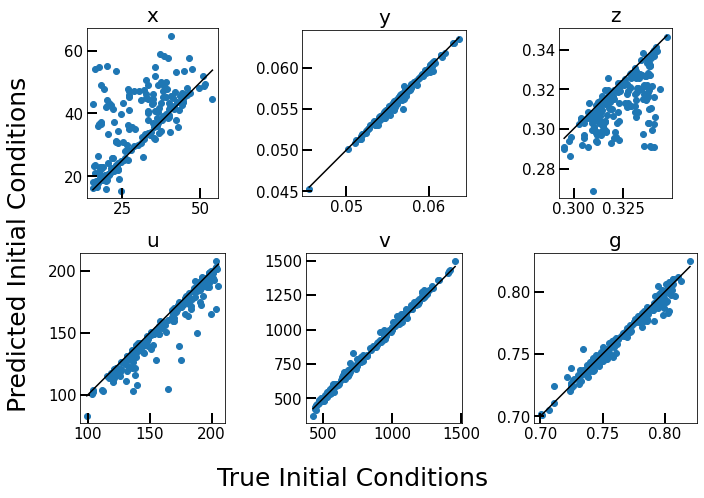

In [47]:
fig = plt.figure(figsize=(10,7))

labels = ['x', 'y', 'z', 'u', 'v', 'g']
for i in range(6):
    ax = plt.subplot(int(str(23) + str(i+1)))
    ax.scatter(data_train_detail_x_load[:,0,i], network.inv_norm_func(network.initial_x)[:,i].cpu().detach().numpy())
    ax.plot([min(data_train_detail_x_load[:,0,i]), max(data_train_detail_x_load[:,0,i])], [min(data_train_detail_x_load[:,0,i]), max(data_train_detail_x_load[:,0,i])], 'k-')
    ax.set_title(labels[i], fontsize=20)
    # ax.xtickformat(fontsize=20)
    ax.tick_params(axis='both', which='major', labelsize=15, direction='in', length=10, width=2)
    ax.set_aspect("equal", adjustable="box")

fig.supxlabel("True Initial Conditions", fontsize=25)
fig.supylabel("Predicted Initial Conditions", fontsize=25)
# fig.suptitle('Prediction of initial conditions', fontsize=25)
plt.tight_layout(pad=1.5)
plt.savefig(save_filename + 'Prediction_of_InitialCondition_Model_Run_' 
        + str(BB_bestcase) + '.png', bbox_extra_artists=(lgd,), bbox_inches='tight')
plt.show()

In [42]:
from BandFModel.datagen import ode_fun, par_fun

index = 5    
tspan = [dataset_train_load.full_times_arr[index][0],
         dataset_train_load.full_times_arr[index][-1]/5]

def ode_NN_func(t,x,p):
    x_in = torch.tensor(x).reshape((-1,6)).to(network.device)
    p_in = torch.tensor(p).reshape((-1,1)).to(network.device)
    return network.output(x_in, p_in).cpu().detach().numpy()

sol_pred = solve_ivp(ode_NN_func, y0=data_train_detail_x_load[index,0,:], 
                t_span=tspan, 
                args=(dataset_train_load.p[[index],[0],[0]],), 
                rtol=1e-10, atol=1e-10)

initial = network.inv_norm_func(network.initial_x[index,:]).detach().cpu().numpy()
sol_pred_init = solve_ivp(ode_NN_func, y0=initial, 
                t_span=tspan, 
                args=(dataset_train_load.p[[index],[0],[0]],), 
                rtol=1e-10, atol=1e-10)

a,b,c,d,e,f = dataset_train_load.x[index,0,:]
sol_true = solve_ivp(ode_fun, y0=data_train_detail_x_load[index,0,:], 
                t_span=tspan, 
                args=(par_fun(D=1/dataset_train_load.p[[index],[0],[0]], sf=2.5),), 
                rtol=1e-10, atol=1e-10)
sol_true_initial = solve_ivp(ode_fun, y0=initial, 
                t_span=tspan, 
                args=(par_fun(D=1/dataset_train_load.p[[index],[0],[0]], sf=2.5),), 
                rtol=1e-10, atol=1e-10)

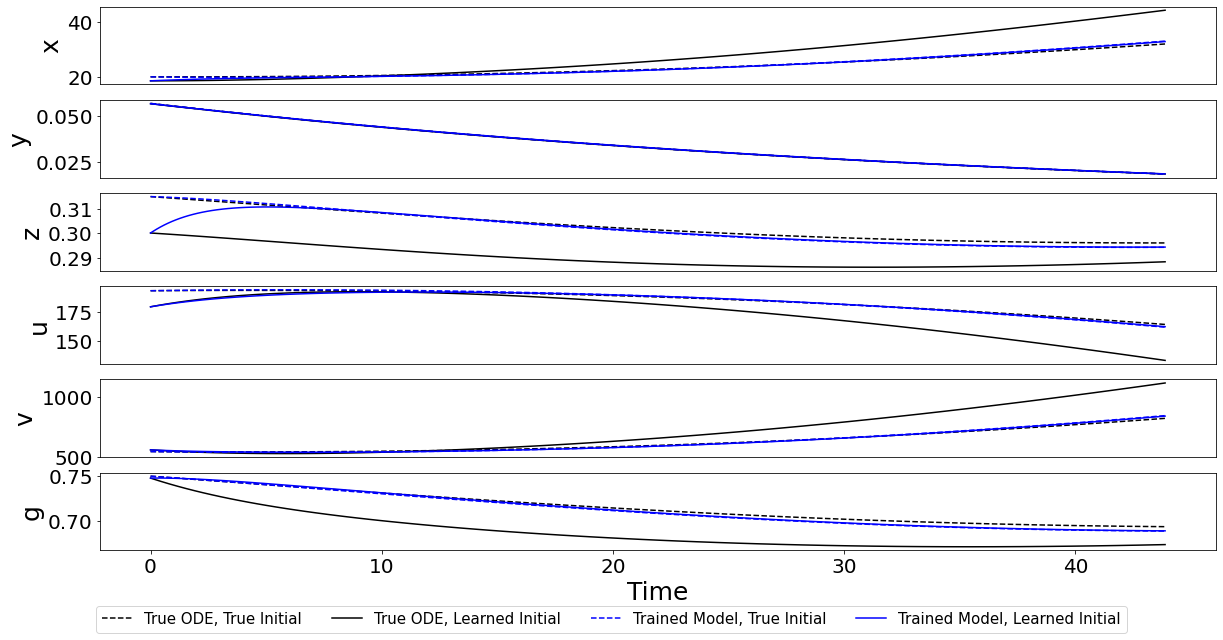

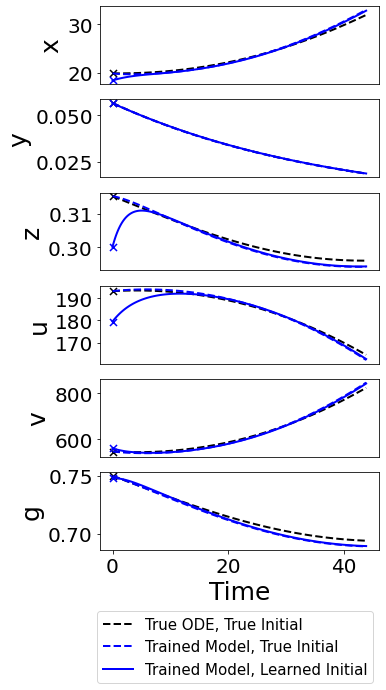

In [43]:
fig = plt.figure(figsize=(20,10))
labels = ['x', 'y', 'z', 'u', 'v', 'g']
for i in range(6):
    ax = plt.subplot(int(str(61) + str(i+1)))
    ax.plot(sol_true.t, sol_true.y[i,:], 'k--', label='True ODE, True Initial')
    ax.plot(sol_true_initial.t, sol_true_initial.y[i,:], 'k', label='True ODE, Learned Initial')
    ax.set_ylabel(labels[i], color='k', fontsize=25)
    ax.tick_params(axis='y', labelsize=20)                              
    if i<5:
        ax.set_xticks([])

    ax.plot(sol_pred.t, sol_pred.y[i,:], 'b--', label='Trained Model, True Initial')
    ax.plot(sol_pred_init.t, sol_pred_init.y[i,:], 'b', label='Trained Model, Learned Initial')

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=4, fontsize=15)

plt.xlabel('Time', fontsize=25)
ax.tick_params(axis='x', labelsize=20)
# plt.savefig('Figures/Initial_Condition_Integration_Trajectory_ShortTime_ALL.png')
plt.show()

fig = plt.figure(figsize=(5,10))
labels = ['x', 'y', 'z', 'u', 'v', 'g']
for i in range(6):
    ax = plt.subplot(int(str(61) + str(i+1)))
    ax.plot(sol_true.t, sol_true.y[i,:], 'k--', label='True ODE, True Initial', linewidth=2)
    ax.scatter(sol_true.t[0], sol_true.y[i,:][0], color='k', marker='x', s=50)
    # ax.plot(sol_true_initial.t, sol_true_initial.y[i,:], 'k', label='True ODE, Learned Initial')
    ax.set_ylabel(labels[i], color='k', fontsize=25)
    ax.tick_params(axis='y', labelsize=20)                              
    if i<5:
        ax.set_xticks([])

    ax.plot(sol_pred.t, sol_pred.y[i,:], 'b--', label='Trained Model, True Initial', linewidth=2)
    ax.scatter(sol_pred_init.t[0], sol_pred_init.y[i,:][0], color='b', marker='x', s=50)
    ax.plot(sol_pred_init.t, sol_pred_init.y[i,:], 'b', label='Trained Model, Learned Initial', linewidth=2)

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=1, fontsize=15, bbox_to_anchor=(0.5, -0.07))

plt.xlabel('Time', fontsize=25)
ax.tick_params(axis='x', labelsize=20)
plt.savefig(save_filename + 'initcondition_short' 
        + str(BB_bestcase) + '.png', bbox_extra_artists=(lgd,), bbox_inches='tight')
plt.show()





In [36]:
index = 5    
tspan = [dataset_train_load.full_times_arr[index][0],
         dataset_train_load.full_times_arr[index][-1]*3]

def ode_NN_func(t,x,p):
    x_in = torch.tensor(x).reshape((-1,6)).to(network.device)
    p_in = torch.tensor(p).reshape((-1,1)).to(network.device)
    return network.output(x_in, p_in).cpu().detach().numpy()

sol_pred = solve_ivp(ode_NN_func, y0=data_train_detail_x_load[index,0,:], 
                t_span=tspan, 
                args=(dataset_train_load.p[[index],[0],[0]],), 
                rtol=1e-10, atol=1e-10)

initial = network.inv_norm_func(network.initial_x[index,:]).detach().cpu().numpy()
sol_pred_init = solve_ivp(ode_NN_func, y0=initial, 
                t_span=tspan, 
                args=(dataset_train_load.p[[index],[0],[0]],), 
                rtol=1e-10, atol=1e-10)

a,b,c,d,e,f = dataset_train_load.x[index,0,:]
sol_true = solve_ivp(ode_fun, y0=data_train_detail_x_load[index,0,:], 
                t_span=tspan, 
                args=(par_fun(D=1/dataset_train_load.p[[index],[0],[0]], sf=2.5),), 
                rtol=1e-10, atol=1e-10)
sol_true_initial = solve_ivp(ode_fun, y0=initial, 
                t_span=tspan, 
                args=(par_fun(D=1/dataset_train_load.p[[index],[0],[0]], sf=2.5),), 
                rtol=1e-10, atol=1e-10)

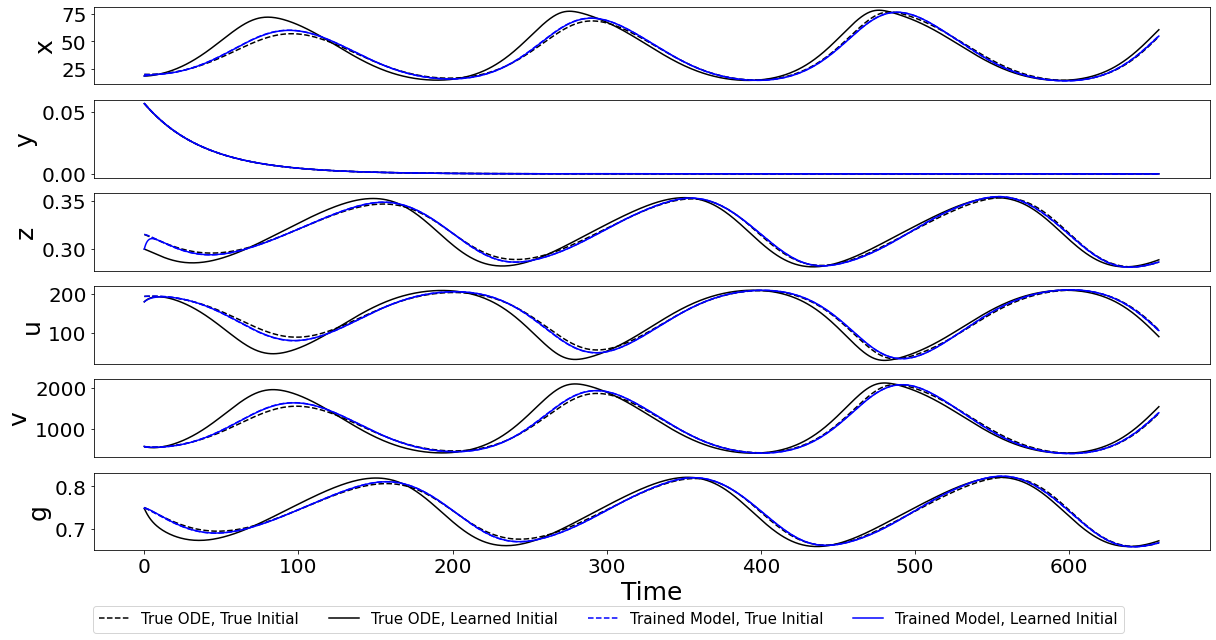

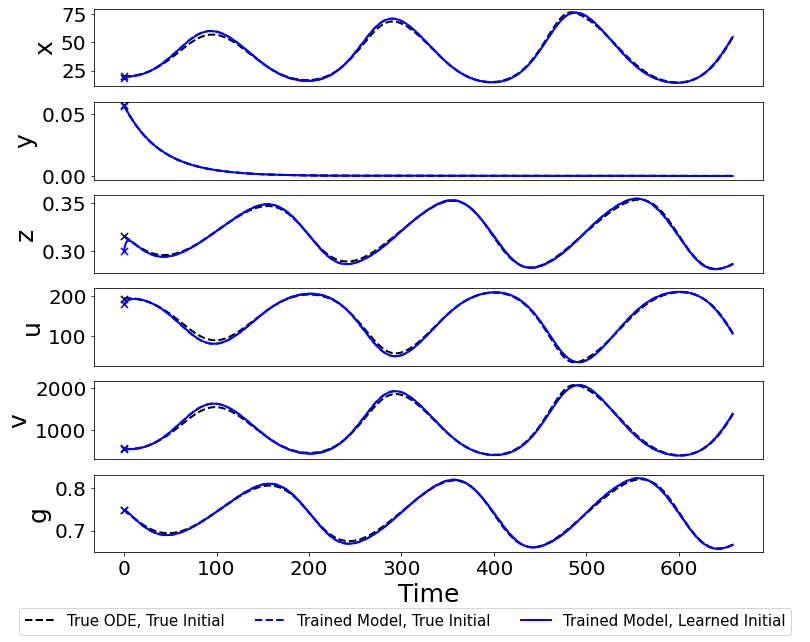

In [41]:
fig = plt.figure(figsize=(20,10))
labels = ['x', 'y', 'z', 'u', 'v', 'g']
for i in range(6):
    ax = plt.subplot(int(str(61) + str(i+1)))
    ax.plot(sol_true.t, sol_true.y[i,:], 'k--', label='True ODE, True Initial')
    ax.plot(sol_true_initial.t, sol_true_initial.y[i,:], 'k', label='True ODE, Learned Initial')
    ax.set_ylabel(labels[i], color='k', fontsize=25)
    ax.tick_params(axis='y', labelsize=20)
    if i<5:
        ax.set_xticks([])

    ax.plot(sol_pred.t, sol_pred.y[i,:], 'b--', label='Trained Model, True Initial')
    ax.plot(sol_pred_init.t, sol_pred_init.y[i,:], 'b', label='Trained Model, Learned Initial')

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=4, fontsize=15)

plt.xlabel('Time', fontsize=25)
ax.tick_params(axis='x', labelsize=20)
# plt.savefig('Figures/Initial_Condition_Integration_Trajectory_LongTime_ALL.png')
plt.show()

fig = plt.figure(figsize=(12,10))
labels = ['x', 'y', 'z', 'u', 'v', 'g']
for i in range(6):
    ax = plt.subplot(int(str(61) + str(i+1)))
    ax.plot(sol_true.t, sol_true.y[i,:], 'k--', label='True ODE, True Initial', linewidth=2)
    ax.scatter(sol_true.t[0], sol_true.y[i,:][0], color='k', marker='x', s=50)
    # ax.plot(sol_true_initial.t, sol_true_initial.y[i,:], 'k', label='True ODE, Learned Initial')
    ax.set_ylabel(labels[i], color='k', fontsize=25)
    ax.tick_params(axis='y', labelsize=20)
    if i<5:
        ax.set_xticks([])

    ax.plot(sol_pred.t, sol_pred.y[i,:], 'b--', label='Trained Model, True Initial', linewidth=2)
    ax.scatter(sol_pred_init.t[0], sol_pred_init.y[i,:][0], color='b', marker='x', s=50)
    ax.plot(sol_pred_init.t, sol_pred_init.y[i,:], 'b', label='Trained Model, Learned Initial', linewidth=2)



handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=4, fontsize=15)

plt.xlabel('Time', fontsize=25)
ax.tick_params(axis='x', labelsize=20)

plt.savefig(save_filename + 'initcondition_long' 
        + str(BB_bestcase) + '.png', bbox_extra_artists=(lgd,), bbox_inches='tight')
# plt.savefig('Figures/Initial_Condition_Integration_Trajectory_LongTime_PredOnly.png')
plt.show()